# Naive Bayes & LDA: Silicon Defect Classification## Multi-Class Defect Routing with Probabilistic Models**Project:** 008 — The AI Engineering Lab  **Objective:** Classify silicon defect types using Naive Bayes and LDA.  **Advanced Concepts:** Prior/likelihood/posterior analysis, LDA Fisher's criterion, calibration.

---## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

COLORS = {'primary': '#0D47A1', 'highlight': '#C62828'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Libraries loaded.')

Libraries loaded.


---## 2. Load Data

In [2]:
df = pd.read_csv('../data/silicon_defect_classification.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
target_col = df.columns[-1]
print(f'\nTarget ({target_col}):\n{df[target_col].value_counts().to_string()}')

Shape: (6000, 6)
Columns: ['particle_size_um', 'leakage_current_pa', 'breakdown_voltage_v', 'local_yield', 'layer_depth', 'defect_type']

Target (defect_type):
defect_type
Clean_Die          2000
Particle_Defect    1000
Oxide_Pinhole       900
Gate_Oxide_Trap     800
Metal_Short         700
Via_Open            600


In [3]:
feature_cols = [c for c in df.columns if c != target_col]
le = LabelEncoder()
y = le.fit_transform(df[target_col])
X = df[feature_cols].select_dtypes(include=[np.number])
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f'Features: {feature_names}')
print(f'Classes ({len(le.classes_)}): {le.classes_.tolist()}')

Features: ['particle_size_um', 'leakage_current_pa', 'breakdown_voltage_v', 'local_yield', 'layer_depth']
Classes (6): ['Clean_Die', 'Gate_Oxide_Trap', 'Metal_Short', 'Oxide_Pinhole', 'Particle_Defect', 'Via_Open']


---## 3. EDA

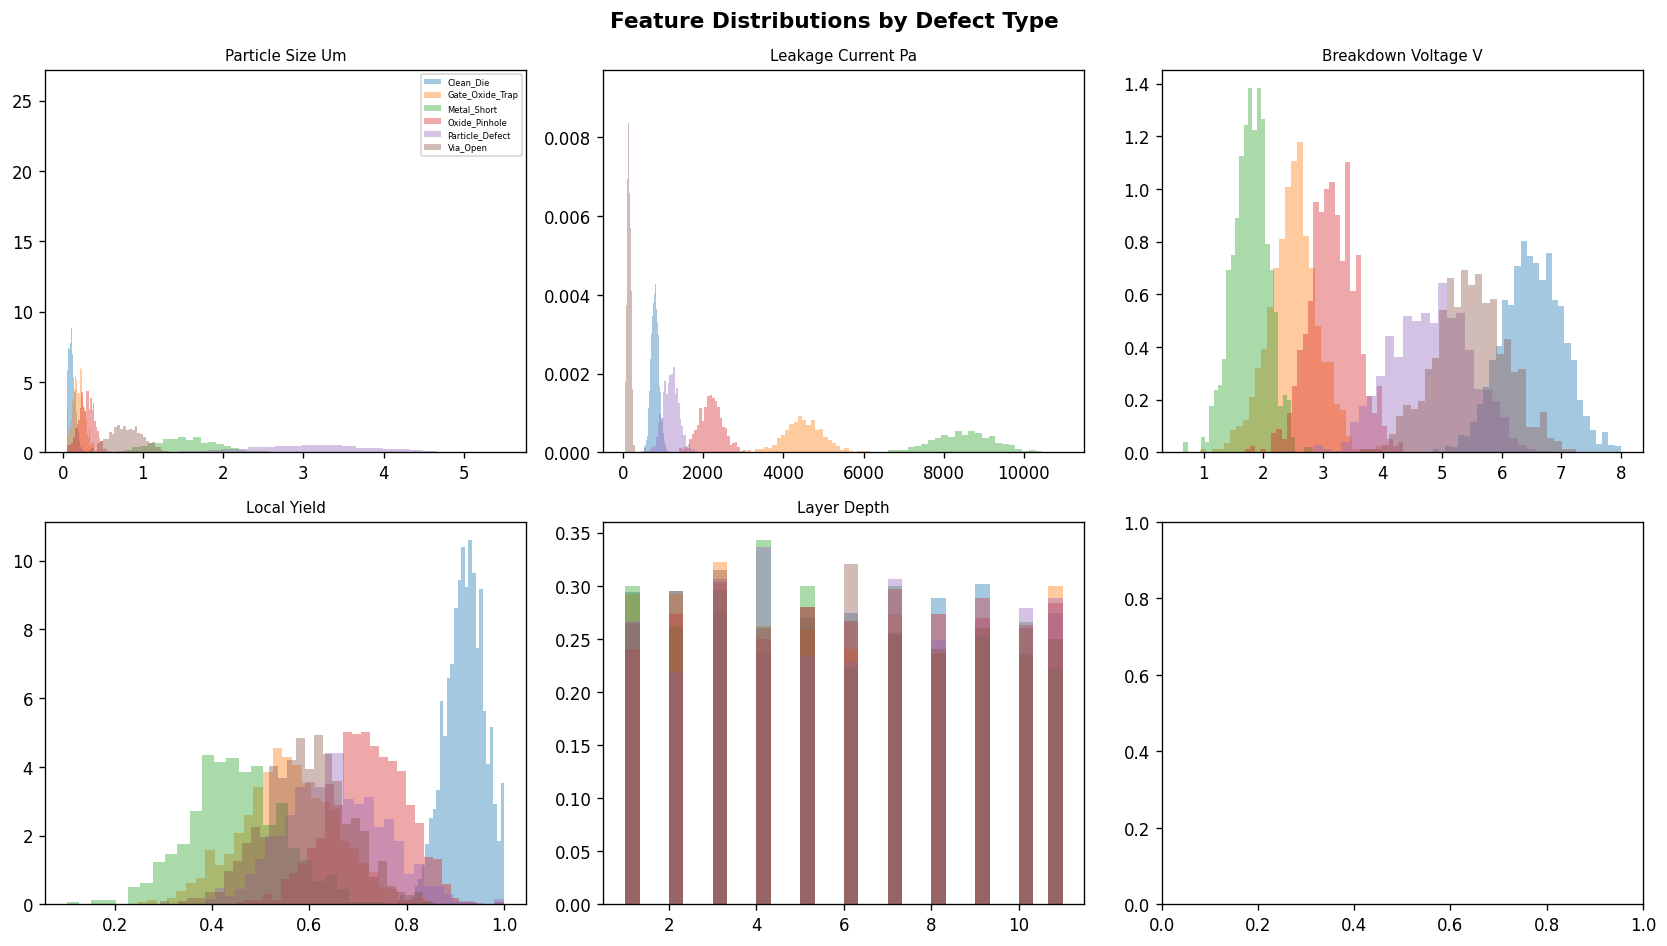

In [4]:
n_plot = min(6, len(feature_names))
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i in range(n_plot):
    ax = axes[i // 3, i % 3]
    for cls_idx, cls_name in enumerate(le.classes_):
        ax.hist(X[y == cls_idx][feature_names[i]], bins=30, alpha=0.4, label=cls_name, density=True)
    ax.set_title(feature_names[i].replace('_', ' ').title(), fontsize=9)
    if i == 0:
        ax.legend(fontsize=5)
plt.suptitle('Feature Distributions by Defect Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/eda_silicon_defect.png', dpi=150, bbox_inches='tight')
plt.show()

---## 4. Models

In [5]:
gnb = GaussianNB()
gnb.fit(X_train_s, y_train)
y_pred_gnb = gnb.predict(X_test_s)
gnb_acc = accuracy_score(y_test, y_pred_gnb)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_s, y_train)
y_pred_lda = lda.predict(X_test_s)
lda_acc = accuracy_score(y_test, y_pred_lda)

print(f'Gaussian NB: {gnb_acc:.3f}')
print(f'LDA: {lda_acc:.3f}')

Gaussian NB: 1.000
LDA: 0.991


---## 5. LDA Projection

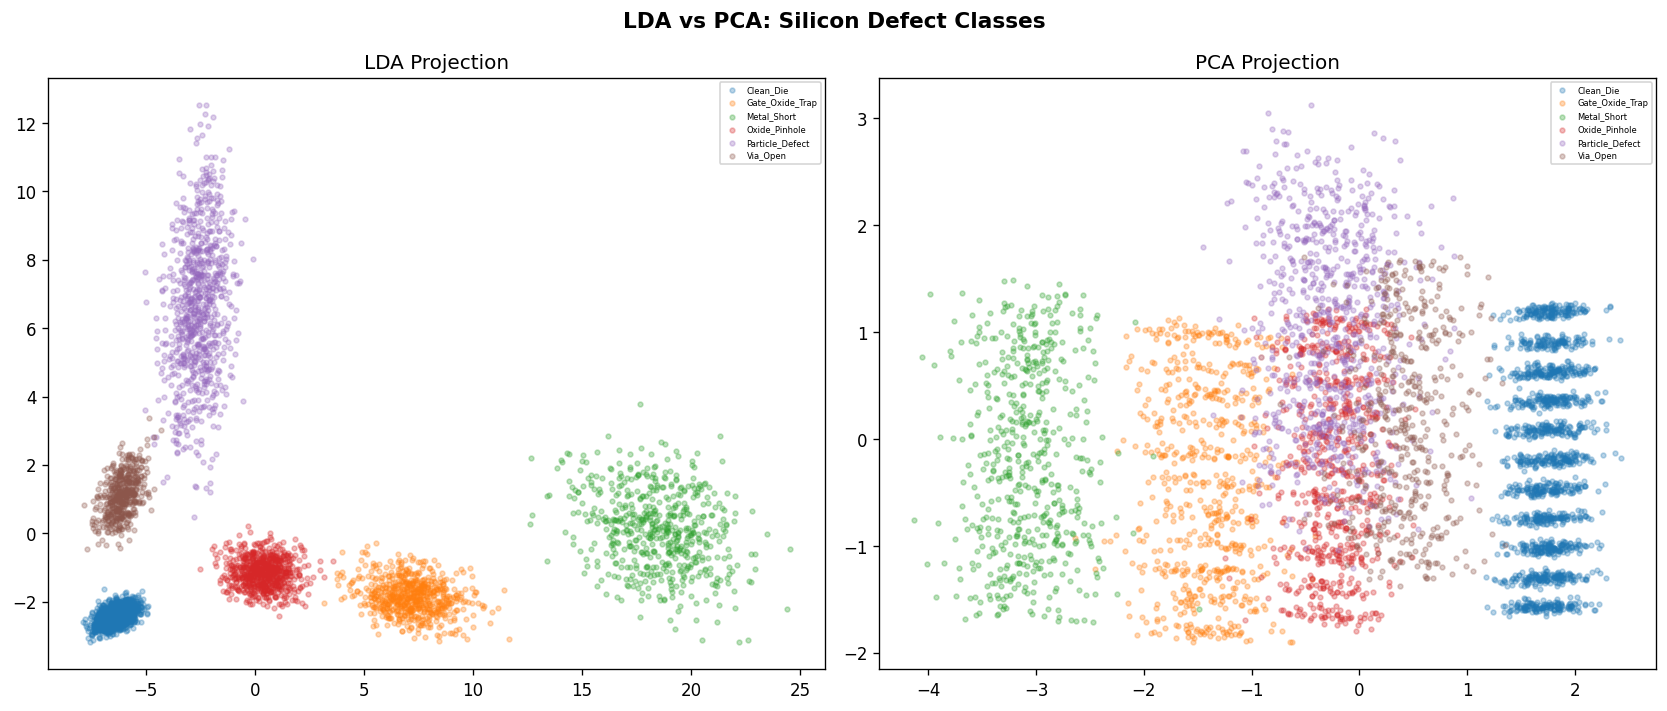

In [6]:
n_comp = min(2, len(le.classes_) - 1, X_train_s.shape[1])
lda_proj = LinearDiscriminantAnalysis(n_components=n_comp)
X_lda = lda_proj.fit_transform(X_train_s, y_train)
X_pca = PCA(n_components=2).fit_transform(X_train_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for cls_idx, cls_name in enumerate(le.classes_):
    mask = y_train == cls_idx
    if n_comp >= 2:
        axes[0].scatter(X_lda[mask, 0], X_lda[mask, 1], alpha=0.3, s=8, label=cls_name)
    else:
        axes[0].scatter(X_lda[mask, 0], np.random.normal(0, 0.1, mask.sum()), alpha=0.3, s=8, label=cls_name)
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.3, s=8, label=cls_name)
axes[0].set_title('LDA Projection'); axes[0].legend(fontsize=5)
axes[1].set_title('PCA Projection'); axes[1].legend(fontsize=5)
plt.suptitle('LDA vs PCA: Silicon Defect Classes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/lda_vs_pca_silicon.png', dpi=150, bbox_inches='tight')
plt.show()

---## 6. Confusion Matrices

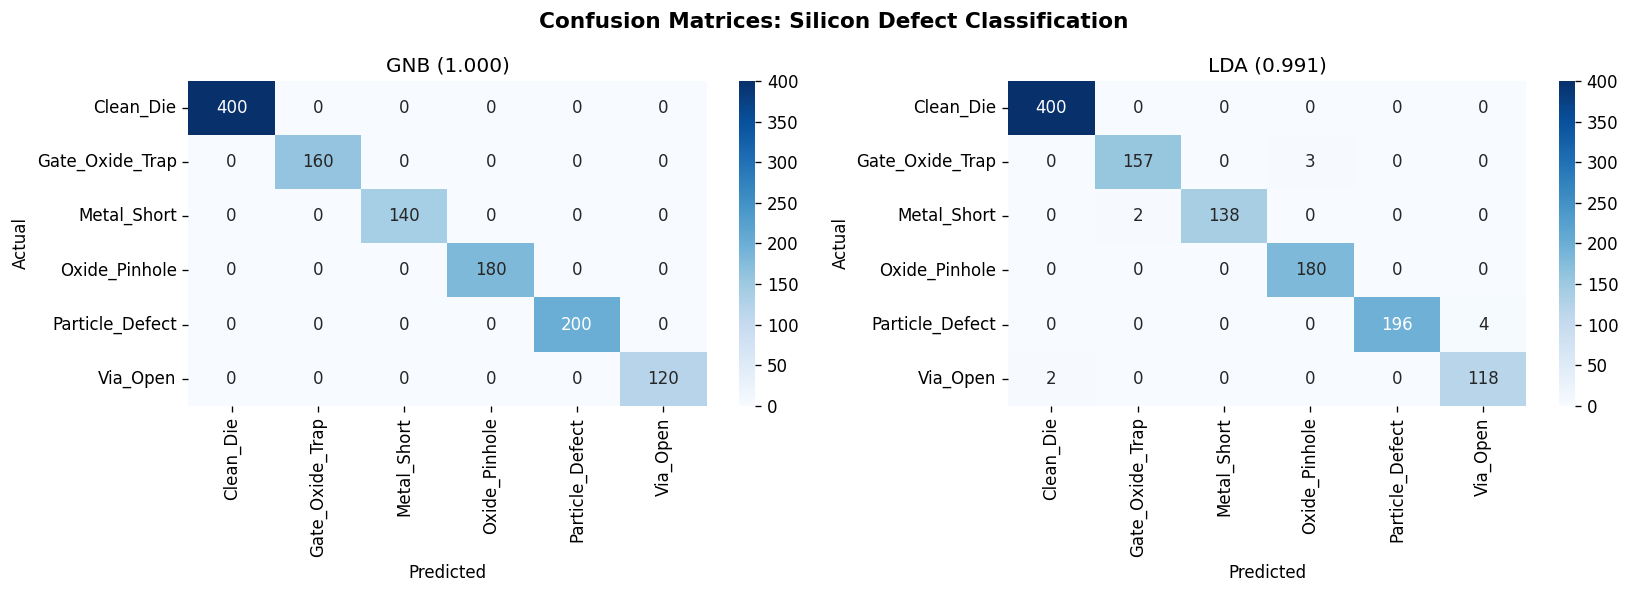

GNB: 1.000 | LDA: 0.991
Notebook complete.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(axes, [y_pred_gnb, y_pred_lda], [f'GNB ({gnb_acc:.3f})', f'LDA ({lda_acc:.3f})']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices: Silicon Defect Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/confusion_silicon.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'GNB: {gnb_acc:.3f} | LDA: {lda_acc:.3f}')
print('Notebook complete.')